In [1]:
import pandas as pd
from os import scandir
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


In [24]:
img = cv.imread('data/NV/ISIC_0000008.jpg')
RGBimg = cv.cvtColor(img, cv.COLOR_BGR2RGB)
RGBimg_flat = RGBimg.reshape(-1, 3)


In [25]:
kmeans = KMeans(n_clusters=10).fit(RGBimg_flat)
raimbov = np.empty((RGBimg_flat.shape))
for k in range(kmeans.n_clusters):
    idx = np.nonzero(kmeans.labels_ == k)
    raimbov[idx] = np.rint(np.mean(RGBimg_flat[idx], axis=0))
raimbov = np.uint8(raimbov.reshape(img.shape))

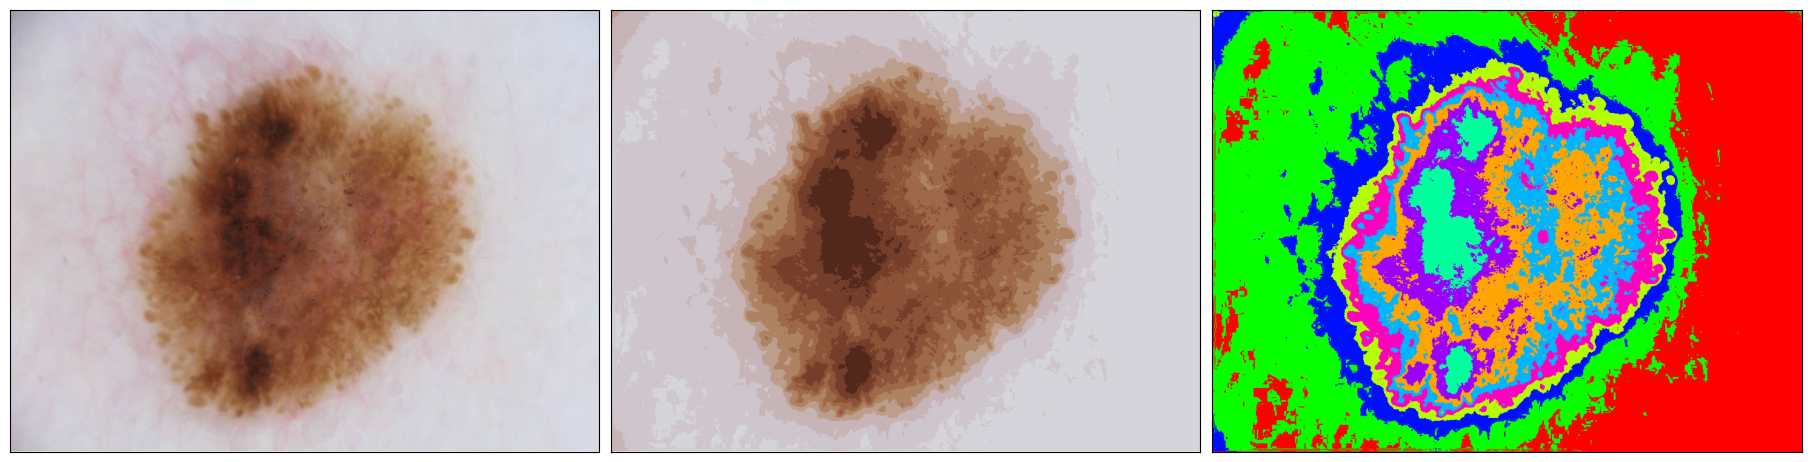

In [32]:
fig, ax = plt.subplots(1, 3, figsize=(18,6), layout='constrained')
ax[0].imshow(RGBimg)
ax[1].imshow(raimbov)
ax[2].imshow(kmeans.labels_.reshape(img.shape[:-1]), cmap='hsv')
for Ax in ax:
    Ax.set_xticks([])
    Ax.set_yticks([])
plt.show()

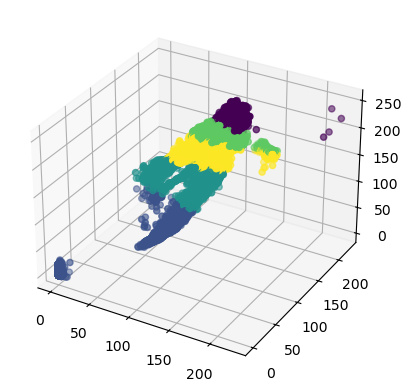

In [18]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(img[:,0], img[:,1], img[:,2], c=kmeans.labels_)
plt.show()

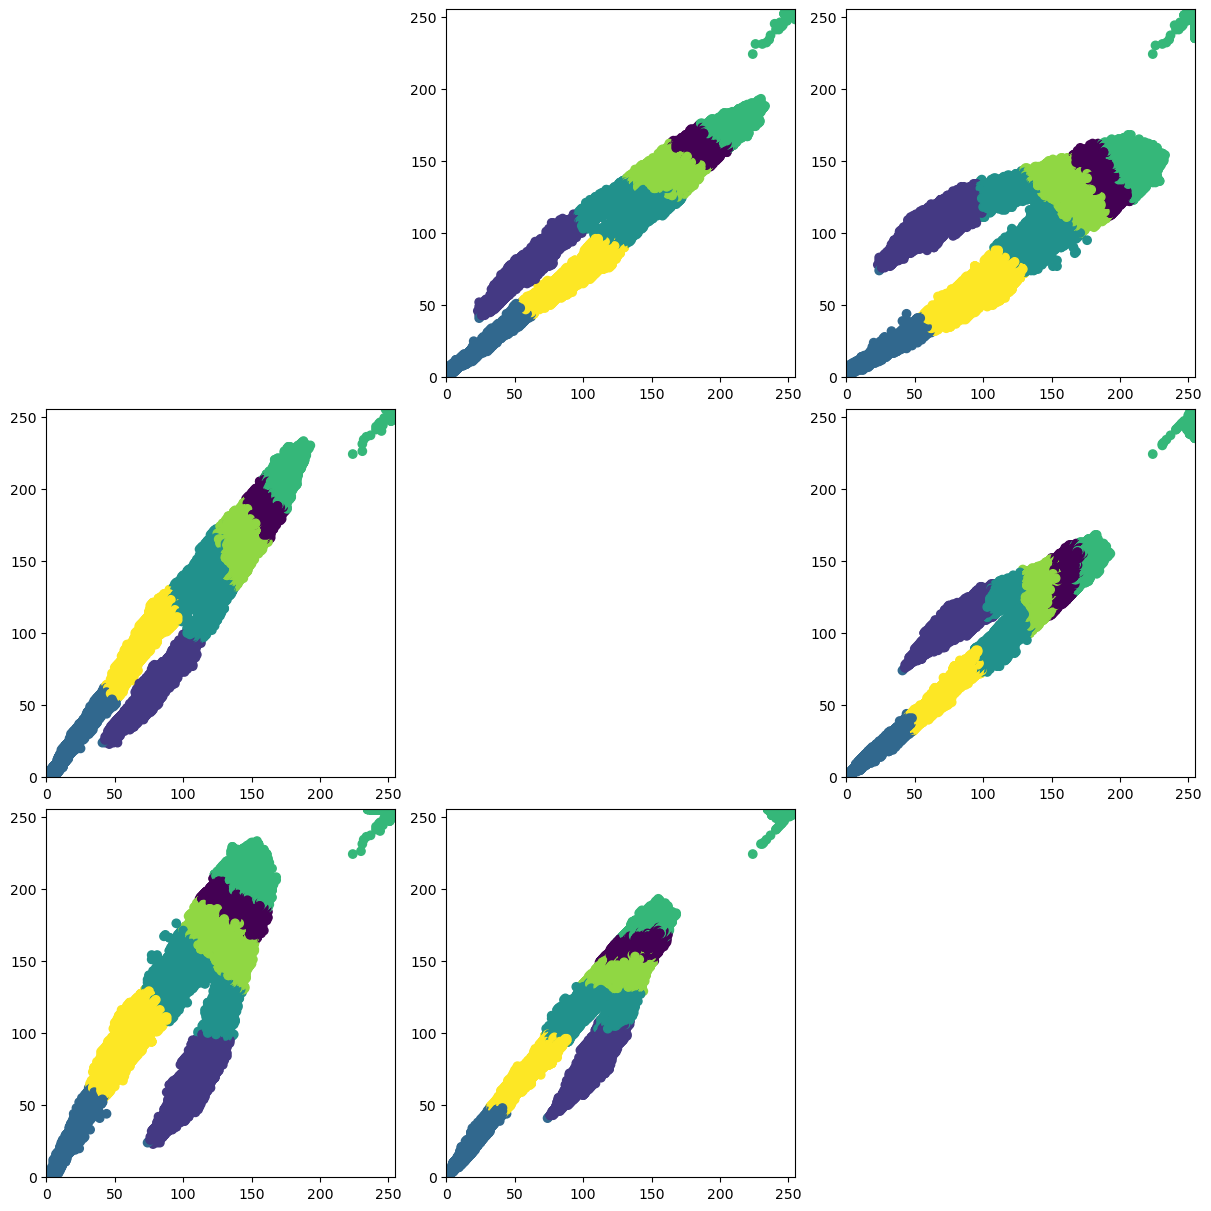

In [16]:
fig, ax = plt.subplots(3, 3, layout='constrained', figsize=(12,12))
for i in range(3):
    for j in range(3):
        if i == j: ax[i,j].remove()
        ax[i, j].scatter(img[..., i], img[..., j], c=kmeans.labels_)
        ax[i, j].set_xlim(0,255)
        ax[i, j].set_ylim(0,255)
plt.show()